<a href="https://colab.research.google.com/github/harshanimudannayaka4-ux/Pyspark-practicles/blob/main/EDA_PySpark_Display.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [47]:
spark = SparkSession.builder \
.appName("Titanic EDA") \
.master("local[*]")\
.getOrCreate()

In [5]:
df=spark.read.csv(
    "/content/train.csv",
    header=True,
    inferSchema=True
)

In [6]:
df.show()

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05| NULL|       S|
|          6|       0|     3|    Moran, Mr. James|  male|NULL|    0|    0|      

In [7]:
df.printSchema()

root
 |-- PassengerId: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Pclass: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Ticket: string (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Cabin: string (nullable = true)
 |-- Embarked: string (nullable = true)



In [8]:
df.count()

891

In [9]:
len(df.columns)

12

In [10]:
df.columns

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [11]:
df.describe().show()

+-------+-----------------+-------------------+------------------+--------------------+------+------------------+------------------+-------------------+------------------+-----------------+-----+--------+
|summary|      PassengerId|           Survived|            Pclass|                Name|   Sex|               Age|             SibSp|              Parch|            Ticket|             Fare|Cabin|Embarked|
+-------+-----------------+-------------------+------------------+--------------------+------+------------------+------------------+-------------------+------------------+-----------------+-----+--------+
|  count|              891|                891|               891|                 891|   891|               714|               891|                891|               891|              891|  204|     889|
|   mean|            446.0| 0.3838383838383838| 2.308641975308642|                NULL|  NULL| 29.69911764705882|0.5230078563411896|0.38159371492704824|260318.54916792738| 32.20420

In [12]:
df.select([
    count(when(col(c).isNull(),c)).alias(c)
    for c in df.columns
]).show()

+-----------+--------+------+----+---+---+-----+-----+------+----+-----+--------+
|PassengerId|Survived|Pclass|Name|Sex|Age|SibSp|Parch|Ticket|Fare|Cabin|Embarked|
+-----------+--------+------+----+---+---+-----+-----+------+----+-----+--------+
|          0|       0|     0|   0|  0|177|    0|    0|     0|   0|  687|       2|
+-----------+--------+------+----+---+---+-----+-----+------+----+-----+--------+



In [17]:
print("Total : ",df.count())
print("Distinct : ",df.distinct().count())

Total :  891
Distinct :  891


In [18]:
df.dtypes

[('PassengerId', 'int'),
 ('Survived', 'int'),
 ('Pclass', 'int'),
 ('Name', 'string'),
 ('Sex', 'string'),
 ('Age', 'double'),
 ('SibSp', 'int'),
 ('Parch', 'int'),
 ('Ticket', 'string'),
 ('Fare', 'double'),
 ('Cabin', 'string'),
 ('Embarked', 'string')]

In [19]:
df.select(
    "Name",
    "Age",
    "Fare"
).show()

+--------------------+----+-------+
|                Name| Age|   Fare|
+--------------------+----+-------+
|Braund, Mr. Owen ...|22.0|   7.25|
|Cumings, Mrs. Joh...|38.0|71.2833|
|Heikkinen, Miss. ...|26.0|  7.925|
|Futrelle, Mrs. Ja...|35.0|   53.1|
|Allen, Mr. Willia...|35.0|   8.05|
|    Moran, Mr. James|NULL| 8.4583|
|McCarthy, Mr. Tim...|54.0|51.8625|
|Palsson, Master. ...| 2.0| 21.075|
|Johnson, Mrs. Osc...|27.0|11.1333|
|Nasser, Mrs. Nich...|14.0|30.0708|
|Sandstrom, Miss. ...| 4.0|   16.7|
|Bonnell, Miss. El...|58.0|  26.55|
|Saundercock, Mr. ...|20.0|   8.05|
|Andersson, Mr. An...|39.0| 31.275|
|Vestrom, Miss. Hu...|14.0| 7.8542|
|Hewlett, Mrs. (Ma...|55.0|   16.0|
|Rice, Master. Eugene| 2.0| 29.125|
|Williams, Mr. Cha...|NULL|   13.0|
|Vander Planke, Mr...|31.0|   18.0|
|Masselmani, Mrs. ...|NULL|  7.225|
+--------------------+----+-------+
only showing top 20 rows


In [20]:
df.filter(
    col("Age")>50
).show()

+-----------+--------+------+--------------------+------+----+-----+-----+-----------+--------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|     Ticket|    Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+-----------+--------+-----+--------+
|          7|       0|     1|McCarthy, Mr. Tim...|  male|54.0|    0|    0|      17463| 51.8625|  E46|       S|
|         12|       1|     1|Bonnell, Miss. El...|female|58.0|    0|    0|     113783|   26.55| C103|       S|
|         16|       1|     2|Hewlett, Mrs. (Ma...|female|55.0|    0|    0|     248706|    16.0| NULL|       S|
|         34|       0|     2|Wheadon, Mr. Edwa...|  male|66.0|    0|    0| C.A. 24579|    10.5| NULL|       S|
|         55|       0|     1|Ostby, Mr. Engelh...|  male|65.0|    0|    1|     113509| 61.9792|  B30|       C|
|         95|       0|     3|   Coxon, Mr. Daniel|  male|59.0|    0|    0|     364500|    7.25| NULL|       S|
|

In [21]:
df.filter(
    col("Sex")=="female"
).show()

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+--------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|    Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+--------+-----+--------+
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599| 71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|   7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|    53.1| C123|       S|
|          9|       1|     3|Johnson, Mrs. Osc...|female|27.0|    0|    2|          347742| 11.1333| NULL|       S|
|         10|       1|     2|Nasser, Mrs. Nich...|female|14.0|    1|    0|          237736| 30.0708| NULL|       C|
|         11|       1|     3|Sandstrom, Miss. ...|female| 4.0|    1|    

In [22]:
df.filter(
    col("Survived")==1
).show()

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+--------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|    Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+--------+-----+--------+
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599| 71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|   7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|    53.1| C123|       S|
|          9|       1|     3|Johnson, Mrs. Osc...|female|27.0|    0|    2|          347742| 11.1333| NULL|       S|
|         10|       1|     2|Nasser, Mrs. Nich...|female|14.0|    1|    0|          237736| 30.0708| NULL|       C|
|         11|       1|     3|Sandstrom, Miss. ...|female| 4.0|    1|    

In [24]:
df.filter(
    (col("Sex")=="female") &
    (col("Survived")==1)
    ).show()

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+--------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|    Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+--------+-----+--------+
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599| 71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|   7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|    53.1| C123|       S|
|          9|       1|     3|Johnson, Mrs. Osc...|female|27.0|    0|    2|          347742| 11.1333| NULL|       S|
|         10|       1|     2|Nasser, Mrs. Nich...|female|14.0|    1|    0|          237736| 30.0708| NULL|       C|
|         11|       1|     3|Sandstrom, Miss. ...|female| 4.0|    1|    

In [25]:
df.orderBy(
    col("Fare").desc()
).show()

+-----------+--------+------+--------------------+------+----+-----+-----+--------+--------+---------------+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|  Ticket|    Fare|          Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+--------+--------+---------------+--------+
|        259|       1|     1|    Ward, Miss. Anna|female|35.0|    0|    0|PC 17755|512.3292|           NULL|       C|
|        680|       1|     1|Cardeza, Mr. Thom...|  male|36.0|    0|    1|PC 17755|512.3292|    B51 B53 B55|       C|
|        738|       1|     1|Lesurer, Mr. Gust...|  male|35.0|    0|    0|PC 17755|512.3292|           B101|       C|
|         28|       0|     1|Fortune, Mr. Char...|  male|19.0|    3|    2|   19950|   263.0|    C23 C25 C27|       S|
|         89|       1|     1|Fortune, Miss. Ma...|female|23.0|    3|    2|   19950|   263.0|    C23 C25 C27|       S|
|        342|       1|     1|Fortune, Miss. Al...|female

In [26]:
df.orderBy(
    col("Age")
).show()

+-----------+--------+------+--------------------+------+----+-----+-----+---------------+--------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|         Ticket|    Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+---------------+--------+-----+--------+
|         88|       0|     3|Slocovski, Mr. Se...|  male|NULL|    0|    0|SOTON/OQ 392086|    8.05| NULL|       S|
|        199|       1|     3|"Madigan, Miss. M...|female|NULL|    0|    0|         370370|    7.75| NULL|       Q|
|         96|       0|     3|Shorney, Mr. Char...|  male|NULL|    0|    0|         374910|    8.05| NULL|       S|
|         83|       1|     3|McDermott, Miss. ...|female|NULL|    0|    0|         330932|  7.7875| NULL|       Q|
|        102|       0|     3|"Petroff, Mr. Pas...|  male|NULL|    0|    0|         349215|  7.8958| NULL|       S|
|         46|       0|     3|Rogers, Mr. Willi...|  male|NULL|    0|    0|S.C./A

In [27]:
df.groupBy("Sex").count().show()

+------+-----+
|   Sex|count|
+------+-----+
|female|  314|
|  male|  577|
+------+-----+



In [28]:
df.groupBy("Sex").agg(
    avg("Survived").alias("Survival Rate")
).show()

+------+-------------------+
|   Sex|      Survival Rate|
+------+-------------------+
|female| 0.7420382165605095|
|  male|0.18890814558058924|
+------+-------------------+



In [30]:
df.groupBy("Pclass").agg(
    avg("Age").alias("Average Age")
).show()

+------+------------------+
|Pclass|       Average Age|
+------+------------------+
|     1|38.233440860215055|
|     3| 25.14061971830986|
|     2| 29.87763005780347|
+------+------------------+



In [31]:
df.groupBy("Pclass").agg(
    avg("Fare").alias("Average Fare")
).show()

+------+------------------+
|Pclass|      Average Fare|
+------+------------------+
|     1| 84.15468749999992|
|     3|13.675550101832997|
|     2| 20.66218315217391|
+------+------------------+



In [33]:
df.groupBy("Pclass").agg(
    count("*").alias("Passengers"),
    avg("Fare").alias("Average Fare"),
    max("Fare").alias("Highest Fare"),
    min("Fare").alias("Lowest Fare"),
    avg("Age").alias("Average Age")
).show()

+------+----------+------------------+------------+-----------+------------------+
|Pclass|Passengers|      Average Fare|Highest Fare|Lowest Fare|       Average Age|
+------+----------+------------------+------------+-----------+------------------+
|     1|       216| 84.15468749999992|    512.3292|        0.0|38.233440860215055|
|     3|       491|13.675550101832997|       69.55|        0.0| 25.14061971830986|
|     2|       184| 20.66218315217391|        73.5|        0.0| 29.87763005780347|
+------+----------+------------------+------------+-----------+------------------+



In [36]:
df = df.withColumn(
    "FamilySize",
    col("Sibsp")+col("Parch")+1
)
df.show()

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+----------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|FamilySize|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+----------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|         2|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|         2|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|         1|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|         2|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05| NULL|       S|    

In [38]:
df.stat.corr(
    "Age",
    "Fare"
)

0.135515853527051

In [39]:
df.write.mode("overwrite") \
.option("header",True) \
.csv("Titanic_Clean")

In [40]:
pdf=df.toPandas()

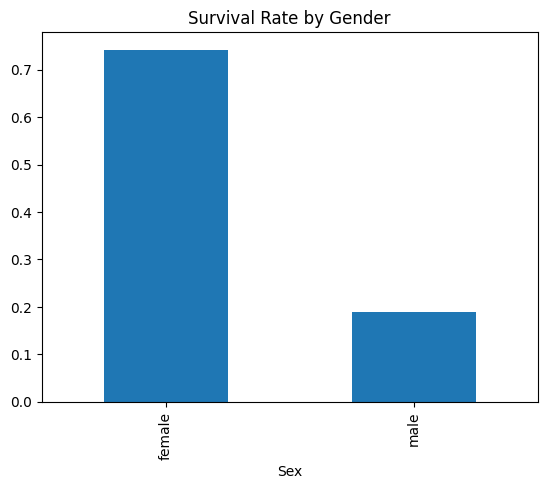

In [42]:
import matplotlib.pyplot as plt
pdf.groupby("Sex")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.show()

In [43]:
!pip install pyspark pandas plotly ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 57.6 MB/s eta 0:00:00


In [44]:
import os
import sys
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display,HTML
import ipywidgets as widgets


In [48]:
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = (
    SparkSession.builder
    .config("spark.python.worker.reuse", "false")
    .config("spark.network.timeout", "300s")
    .config("spark.executor.heartbeatInterval", "60s")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark version:", spark.version)

Spark version: 4.0.4


In [49]:
df.printSchema()

total_records = df.count()
total_columns = len(df.columns)
distinct_records = df.distinct().count()
duplicate_records = total_records - distinct_records

print("Total records:", total_records)
print("Total columns:", total_columns)
print("Distinct records:", distinct_records)
print("Duplicate records:", duplicate_records)

root
 |-- PassengerId: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Pclass: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Ticket: string (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Cabin: string (nullable = true)
 |-- Embarked: string (nullable = true)
 |-- FamilySize: integer (nullable = true)

Total records: 891
Total columns: 13
Distinct records: 891
Duplicate records: 0


In [53]:
clean_df=(df
          .withColumn(
        "SurvivalStatus",
         when(col("Survived") == 1, "Survived")
         .otherwise("Did Not Survive")
    )
    .withColumn(
        "PassengerClass",
         when(col("Pclass") == 1, "First Class")
         .when(col("Pclass") == 2, "Second Class")
         .otherwise("Third Class"))
)

In [54]:
clean_df.show()

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+----------+---------------+--------------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|FamilySize| SurvivalStatus|PassengerClass|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+----------+---------------+--------------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|         2|Did Not Survive|   Third Class|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|         2|       Survived|   First Class|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|         1|       Survived|   Third Class|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|3

In [55]:
missing_df = clean_df.select([
    sum(
        when(col(column).isNull(), 1).otherwise(0)
    ).alias(column)
    for column in clean_df.columns
])

missing_values = missing_df.toPandas().transpose().reset_index()
missing_values.columns = ["Column", "MissingValues"]

missing_values = missing_values.sort_values(
    "MissingValues",
    ascending=False
)

display(missing_values)

,Column,MissingValues
10,Cabin,687
5,Age,177
11,Embarked,2
2,Pclass,0
3,Name,0
1,Survived,0
0,PassengerId,0
6,SibSp,0
4,Sex,0
8,Ticket,0


In [56]:
pdf = clean_df.select(
    "PassengerId",
    "Survived",
    "SurvivalStatus",
    "Pclass",
    "PassengerClass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",
    "FamilySize"
).toPandas()

pdf.head()

,PassengerId,Survived,SurvivalStatus,Pclass,PassengerClass,Sex,Age,Fare,Embarked,FamilySize
0,1,0,Did Not Survive,3,Third Class,male,22.0,7.2500,S,2
1,2,1,Survived,1,First Class,female,38.0,71.2833,C,2
2,3,1,Survived,3,Third Class,female,26.0,7.9250,S,1
3,4,1,Survived,1,First Class,female,35.0,53.1000,S,2
4,5,0,Did Not Survive,3,Third Class,male,35.0,8.0500,S,1


In [59]:
total_passengers = clean_df.count()
survived_passengers = clean_df.filter(col("Survived") == 1).count()
survival_rate = clean_df.select(avg("Survived")).collect()[0][0] * 100
average_age = clean_df.select(avg("Age")).collect()[0][0]

def create_kpi_card(title, value):
    return widgets.HTML(
        value=f"""


                {title}



                {value}


        """
    )


kpi_dashboard = widgets.HBox([
    create_kpi_card("Total Passengers", f"{total_passengers:,}"),
    create_kpi_card("Survived", f"{survived_passengers:,}"),
    create_kpi_card("Survival Rate", f"{survival_rate:.1f}%"),
    create_kpi_card("Average Age", f"{average_age:.1f}"),
    create_kpi_card("Duplicate Records", f"{duplicate_records}")
])

display(kpi_dashboard)

In [60]:
survival_counts = (
    pdf["SurvivalStatus"]
    .value_counts()
    .reset_index()
)

survival_counts.columns = [
    "Survival Status",
    "Passenger Count"
]

fig_survival = px.pie(
    survival_counts,
    names="Survival Status",
    values="Passenger Count",
    title="Passenger Survival Distribution",
    hole=0.4
)

fig_survival.show()

In [61]:
gender_counts = (
    pdf["Sex"]
    .value_counts()
    .reset_index()
)

gender_counts.columns = [
    "Gender",
    "Passenger Count"
]

fig_gender = px.bar(
    gender_counts,
    x="Gender",
    y="Passenger Count",
    title="Passenger Distribution by Gender",
    text="Passenger Count"
)

fig_gender.show()

In [62]:
class_counts = (
    pdf["PassengerClass"]
    .value_counts()
    .reset_index()
)

class_counts.columns = [
    "Passenger Class",
    "Passenger Count"
]

fig_class = px.bar(
    class_counts,
    x="Passenger Class",
    y="Passenger Count",
    title="Passenger Distribution by Class",
    text="Passenger Count"
)

fig_class.show()

In [63]:
gender_survival = (
    pdf.groupby("Sex", as_index=False)["Survived"]
    .mean()
)

gender_survival["Survival Rate (%)"] = (
    gender_survival["Survived"] * 100
)

fig_gender_survival = px.bar(
    gender_survival,
    x="Sex",
    y="Survival Rate (%)",
    title="Survival Rate by Gender",
    text_auto=".1f"
)

fig_gender_survival.show()

In [64]:
class_survival = (
    pdf.groupby(
        ["Pclass", "PassengerClass"],
        as_index=False
    )["Survived"]
    .mean()
)

class_survival["Survival Rate (%)"] = (
    class_survival["Survived"] * 100
)

class_survival = class_survival.sort_values("Pclass")

fig_class_survival = px.bar(
    class_survival,
    x="PassengerClass",
    y="Survival Rate (%)",
    title="Survival Rate by Passenger Class",
    text_auto=".1f"
)

fig_class_survival.show()

In [65]:
fig_age = px.histogram(
    pdf,
    x="Age",
    nbins=30,
    title="Passenger Age Distribution",
    labels={"Age": "Passenger Age"}
)

fig_age.show()

In [66]:
fig_fare = px.histogram(
    pdf,
    x="Fare",
    nbins=40,
    title="Passenger Fare Distribution",
    labels={"Fare": "Fare"}
)

fig_fare.show()

In [67]:
fig_scatter = px.scatter(
    pdf,
    x="Age",
    y="Fare",
    color="SurvivalStatus",
    symbol="PassengerClass",
    title="Relationship Between Age and Fare",
    hover_data=[
        "Sex",
        "PassengerClass",
        "FamilySize"
    ]
)

fig_scatter.show()

In [68]:
missing_chart_data = missing_values[
    missing_values["MissingValues"] > 0
]

fig_missing = px.bar(
    missing_chart_data,
    x="Column",
    y="MissingValues",
    title="Missing Values by Column",
    text="MissingValues"
)

fig_missing.show()

In [69]:
average_age_class = (
    pdf.groupby(
        ["Pclass", "PassengerClass"],
        as_index=False
    )["Age"]
    .mean()
    .sort_values("Pclass")
)

fig_average_age = px.bar(
    average_age_class,
    x="PassengerClass",
    y="Age",
    title="Average Age by Passenger Class",
    labels={"Age": "Average Age"},
    text_auto=".1f"
)

fig_average_age.show()

In [70]:
average_fare_class = (
    pdf.groupby(
        ["Pclass", "PassengerClass"],
        as_index=False
    )["Fare"]
    .mean()
    .sort_values("Pclass")
)

fig_average_fare = px.bar(
    average_fare_class,
    x="PassengerClass",
    y="Fare",
    title="Average Fare by Passenger Class",
    labels={"Fare": "Average Fare"},
    text_auto=".2f"
)

fig_average_fare.show()

In [71]:
embarked_survival = (
    pdf.dropna(subset=["Embarked"])
    .groupby("Embarked", as_index=False)
    .agg(
        Passenger_Count=("PassengerId", "count"),
        Survival_Rate=("Survived", "mean")
    )
)

embarked_survival["Survival Rate (%)"] = (
    embarked_survival["Survival_Rate"] * 100
)

fig_embarked = px.bar(
    embarked_survival,
    x="Embarked",
    y="Survival Rate (%)",
    title="Survival Rate by Embarkation Port",
    text_auto=".1f",
    hover_data=["Passenger_Count"]
)

fig_embarked.show()

In [72]:
gender_filter = widgets.Dropdown(
    options=[
        ("All Genders", "All"),
        ("Male", "male"),
        ("Female", "female")
    ],
    value="All",
    description="Gender:"
)

class_filter = widgets.Dropdown(
    options=[
        ("All Classes", "All"),
        ("First Class", 1),
        ("Second Class", 2),
        ("Third Class", 3)
    ],
    value="All",
    description="Class:"
)

output_area = widgets.Output()

In [73]:
def update_dashboard(change=None):

    filtered_pdf = pdf.copy()

    if gender_filter.value != "All":
        filtered_pdf = filtered_pdf[
            filtered_pdf["Sex"] == gender_filter.value
        ]

    if class_filter.value != "All":
        filtered_pdf = filtered_pdf[
            filtered_pdf["Pclass"] == class_filter.value
        ]

    with output_area:

        output_area.clear_output(wait=True)

        filtered_total = len(filtered_pdf)

        filtered_survived = int(
            filtered_pdf["Survived"].sum()
        )

        filtered_survival_rate = (
            filtered_survived / filtered_total * 100
            if filtered_total > 0
            else 0
        )

        filtered_average_age = filtered_pdf["Age"].mean()
        filtered_average_fare = filtered_pdf["Fare"].mean()

        display(
            widgets.HBox([
                create_kpi_card(
                    "Filtered Passengers",
                    f"{filtered_total:,}"
                ),
                create_kpi_card(
                    "Filtered Survivors",
                    f"{filtered_survived:,}"
                ),
                create_kpi_card(
                    "Survival Rate",
                    f"{filtered_survival_rate:.1f}%"
                ),
                create_kpi_card(
                    "Average Age",
                    (
                        f"{filtered_average_age:.1f}"
                        if pd.notna(filtered_average_age)
                        else "N/A"
                    )
                ),
                create_kpi_card(
                    "Average Fare",
                    (
                        f"{filtered_average_fare:.2f}"
                        if pd.notna(filtered_average_fare)
                        else "N/A"
                    )
                )
            ])
        )

        filtered_survival_counts = (
            filtered_pdf["SurvivalStatus"]
            .value_counts()
            .reset_index()
        )

        filtered_survival_counts.columns = [
            "Survival Status",
            "Passenger Count"
        ]

        figure_one = px.pie(
            filtered_survival_counts,
            names="Survival Status",
            values="Passenger Count",
            title="Filtered Survival Distribution",
            hole=0.4
        )

        figure_two = px.histogram(
            filtered_pdf,
            x="Age",
            color="SurvivalStatus",
            nbins=25,
            title="Filtered Age Distribution"
        )

        figure_three = px.box(
            filtered_pdf,
            x="PassengerClass",
            y="Fare",
            color="SurvivalStatus",
            title="Fare Distribution by Passenger Class"
        )

        figure_one.show()
        figure_two.show()
        figure_three.show()


gender_filter.observe(
    update_dashboard,
    names="value"
)

class_filter.observe(
    update_dashboard,
    names="value"
)

display(
    widgets.VBox([
        widgets.HTML("Interactive Titanic EDA Dashboard"),
        widgets.HBox([
            gender_filter,
            class_filter
        ]),
        output_area
    ])
)

update_dashboard()

In [74]:
from google.colab import output
output.enable_custom_widget_manager()

In [75]:
survival_widget = go.FigureWidget(fig_survival.to_dict())
gender_widget = go.FigureWidget(fig_gender.to_dict())
class_widget = go.FigureWidget(fig_class.to_dict())

gender_survival_widget = go.FigureWidget(fig_gender_survival.to_dict())
class_survival_widget = go.FigureWidget(fig_class_survival.to_dict())

age_widget = go.FigureWidget(fig_age.to_dict())
fare_widget = go.FigureWidget(fig_fare.to_dict())

scatter_widget = go.FigureWidget(fig_scatter.to_dict())
missing_widget = go.FigureWidget(fig_missing.to_dict())

average_age_widget = go.FigureWidget(fig_average_age.to_dict())
average_fare_widget = go.FigureWidget(fig_average_fare.to_dict())

embarked_widget = go.FigureWidget(fig_embarked.to_dict())

In [76]:
dashboard_figures = [
    survival_widget,
    gender_widget,
    class_widget,
    gender_survival_widget,
    class_survival_widget,
    age_widget,
    fare_widget,
    scatter_widget,
    missing_widget,
    average_age_widget,
    average_fare_widget,
    embarked_widget
]

for figure in dashboard_figures:
    figure.layout.height = 400
    figure.layout.width = None
    figure.layout.margin = dict(
        l=30,
        r=30,
        t=60,
        b=40
    )

In [77]:
def chart_container(fig_widget):
    return widgets.VBox(
        [fig_widget],
        layout=widgets.Layout(
            border="1px solid #d9d9d9",
            border_radius="10px",
            padding="10px",
            margin="5px",
            flex_grow="1"
        )
    )

row_one = widgets.HBox(
    [
        chart_container(survival_widget),
        chart_container(gender_widget)
    ],
    layout=widgets.Layout(
        width="100%",
        display="flex",
        flex_flow="row wrap"
    )
)

row_two = widgets.HBox(
    [
        chart_container(class_widget),
        chart_container(missing_widget)
    ],
    layout=widgets.Layout(
        width="100%",
        display="flex",
        flex_flow="row wrap"
    )
)

row_three = widgets.HBox(
    [
        chart_container(age_widget),
        chart_container(fare_widget)
    ],
    layout=widgets.Layout(
        width="100%",
        display="flex",
        flex_flow="row wrap"
    )
)

row_four = widgets.HBox(
    [
        chart_container(gender_survival_widget),
        chart_container(class_survival_widget)
    ],
    layout=widgets.Layout(
        width="100%",
        display="flex",
        flex_flow="row wrap"
    )
)

row_five = widgets.HBox(
    [
        chart_container(average_age_widget),
        chart_container(average_fare_widget)
    ],
    layout=widgets.Layout(
        width="100%",
        display="flex",
        flex_flow="row wrap"
    )
)

row_six = widgets.HBox(
    [
        chart_container(scatter_widget),
        chart_container(embarked_widget)
    ],
    layout=widgets.Layout(
        width="100%",
        display="flex",
        flex_flow="row wrap"
    )
)

In [78]:
dashboard_title = widgets.HTML(
    value="""


            Titanic Dataset EDA Dashboard



            Exploratory Data Analysis using PySpark,
            pandas and Plotly


    """
)

In [79]:
complete_dashboard = widgets.VBox(
    [
        dashboard_title,
        kpi_dashboard,
        row_one,
        row_two,
        row_three,
        row_four,
        row_five,
        row_six
    ],
    layout=widgets.Layout(
        width="100%",
        padding="10px",
        border="1px solid #eeeeee"
    )
)

display(complete_dashboard)